In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

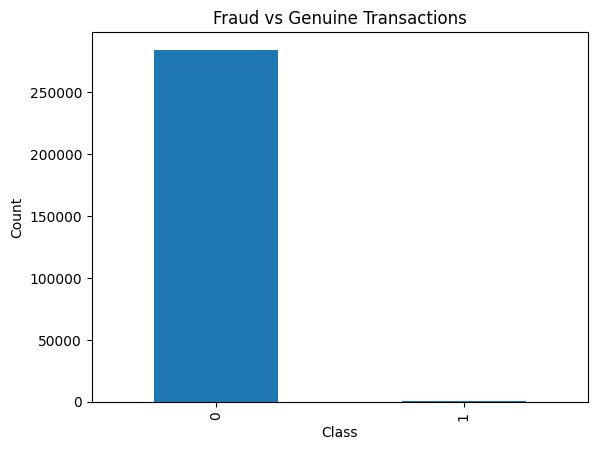

In [9]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

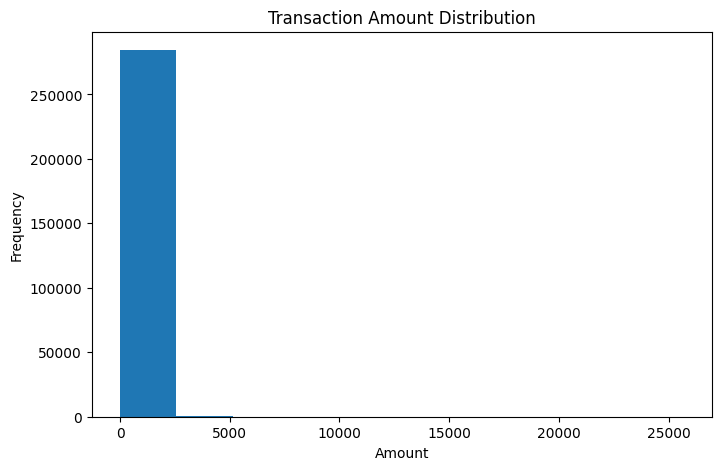

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['Amount'], bins=10)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
y_train.value_counts()

(227845, 30)


Class
0    227451
1       394
Name: count, dtype: int64

In [6]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train))
X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test))

In [9]:
import numpy as np

X_test_scaled = pd.DataFrame(X_test_scaled)
y_test = pd.DataFrame(y_test)

X_test_scaled.to_csv('x_test_scaled.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


In [15]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(X_train_resampled.shape)
y_train_resampled.shape

(454902, 30)


(454902,)

In [16]:
y_train_resampled.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [17]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
lr_pred = lr.predict(X_test_scaled)

acc = accuracy_score(y_test, lr_pred)
prec = precision_score(y_test, lr_pred)
rec = recall_score(y_test, lr_pred)
f1 = f1_score(y_test, lr_pred)
conf_matrix = confusion_matrix(y_test, lr_pred)

print("=== Logistic Regression ===")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

=== Logistic Regression ===
Accuracy: 0.9729468768652786
Precision: 0.056
Recall: 0.9285714285714286
F1 Score: 0.10562971561230412
Confusion Matrix:
 [[55330  1534]
 [    7    91]]


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
rf_pred = rf.predict(X_test_scaled)

acc = accuracy_score(y_test, rf_pred)
prec = precision_score(y_test, rf_pred)
rec = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
conf_matrix = confusion_matrix(y_test, rf_pred)

In [ ]:
print("=== Random Forest Classifier ===")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

=== Random Forest Classifier ===
Accuracy: 0.9995786664794073
Precision: 0.9111111111111111
Recall: 0.8367346938775511
F1 Score: 0.8723404255319149
Confusion Matrix:
 [[56856     8]
 [   16    82]]


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train_resampled,
    y_train_resampled
)

xgb_pred = xgb.predict(X_test_scaled)

In [ ]:
print("=== XGBoost ===")
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

=== XGBoost ===
Accuracy : 0.9972613321161476
Precision: 0.3739130434782609
Recall   : 0.8775510204081632
F1 Score : 0.524390243902439
Confusion Matrix:
 [[56720   144]
 [   12    86]]


In [ ]:
results = []

models = {
    "Logistic Regression": (lr, lr_pred),
    "Random Forest": (rf, rf_pred),
    "XGBoost": (xgb, xgb_pred)
}

for name, (model, pred) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
    })


results_df = pd.DataFrame(results)

results_df.to_csv("/kaggle/working/results.csv", index=False)

In [ ]:
best_model = max(
    models.items(),
    key=lambda x: f1_score(
        y_test,
        x[1][1]
    )
)

print("Best Model:", best_model[0])

Best Model: Random Forest


In [ ]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

rf_grid.fit(
    X_train_resampled,
    y_train_resampled
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

In [ ]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest F1:")
print(rf_grid.best_score_)

In [ ]:
best_rf = rf_grid.best_estimator_

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(
    X_train_resampled,
    y_train_resampled
)

In [ ]:
print("Best Parameters for XGBoost (tuned for F1):", xgb_grid.best_params_)
print("Best F1 Score for XGBoost:", xgb_grid.best_score_)

In [ ]:
best_xgb = xgb_grid.best_estimator_

best_xgb_pred = best_xgb.predict(X_test_scaled)

acc_best_xgb = accuracy_score(y_test, best_xgb_pred)
prec_best_xgb = precision_score(y_test, best_xgb_pred)
rec_best_xgb = recall_score(y_test, best_xgb_pred)
f1_best_xgb = f1_score(y_test, best_xgb_pred)
conf_matrix_best_xgb = confusion_matrix(y_test, best_xgb_pred)

print("=== Tuned XGBoost Classifier ===")
print("Accuracy:", acc_best_xgb)
print("Precision:", prec_best_xgb)
print("Recall:", rec_best_xgb)
print("F1 Score:", f1_best_xgb)
print("Confusion Matrix:\n", conf_matrix_best_xgb)

In [ ]:
joblib.dump(best_rf, "rf_fraud_detector.pkl")

In [ ]:
# Assuming best_rf is already defined from previous steps
joblib.dump(best_rf, "rf_fraud_detector.pkl")
joblib.dump(best_xgb, "xgb_fraud_detector.pkl")

print("Best Random Forest model saved to rf_fraud_detector.pkl")
print("Best XGBoost model saved to xgb_fraud_detector.pkl")

In [ ]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

best_rf.fit(X_train, y_train)

joblib.dump(best_rf, "/kaggle/working/best_rf_model2.pkl")

['/kaggle/working/best_rf_model2.pkl']

In [ ]:
best_rf_model = joblib.load("/kaggle/working/best_rf_model2.pkl")

In [ ]:
y_pred = best_rf_model.predict(X_test)

In [ ]:
print("=== Best RandomForest Classifier ===")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F-1 score: ", f1_score(y_test, y_pred))

=== Best RandomForest Classifier ===
Accuracy:  0.9995611109160493
Precision:  0.9866666666666667
Recall:  0.7551020408163265
F-1 score:  0.8554913294797688


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1]
)

best_idx = np.argmax(f1_scores)

print("Best Threshold:", thresholds[best_idx])
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

BEST_THRESHOLD = thresholds[best_idx]

Best Threshold: 0.3
Precision: 0.9425287356321839
Recall: 0.8367346938775511
F1: 0.8864864864864864


In [ ]:
test_df = X_test.copy()
test_df["Class"] = y_test
normal_df = test_df[test_df["Class"] == 0]
fraud_df = test_df[test_df["Class"] == 1]

transactions_per_second = 20
counter = 0

while True:

    start_time = time.time()

    for _ in range(transactions_per_second):

        # 10 normal + 1 fraud
        if counter % 11 == 10:
            row = fraud_df.sample(1)
        else:
            row = normal_df.sample(1)

        counter += 1

        actual_class = int(row["Class"].values[0])

        X_transaction = row.drop("Class", axis=1)

        fraud_prob = model.predict_proba(X_transaction)[0][1]

        prediction = int(fraud_prob >= BEST_THRESHOLD)

        risk_score = round(fraud_prob * 100, 2)

        print(
            f"Actual={actual_class} | "
            f"Probability={fraud_prob:.4f} | "
            f"Risk={risk_score:.2f}% | "
            f"Prediction={prediction}"
        )

        result = pd.DataFrame({
            "timestamp": [datetime.now()],
            "actual_class": [actual_class],
            "fraud_probability": [fraud_prob],
            "risk_score": [risk_score],
            "prediction": [prediction]
        })

        result.to_csv(
            output_file,
            mode="a",
            header=False,
            index=False
        )

    elapsed = time.time() - start_time

    if elapsed < 1:
        time.sleep(1 - elapsed)

Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=1 | Probability=0.9750 | Risk=97.50% | Prediction=1
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Probability=0.0000 | Risk=0.00% | Prediction=0
Actual=0 | Pr

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_probs = best_rf.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

for p,r,t in zip(precision[:-1], recall[:-1], thresholds):
    if r >= 0.90:
        print(t,p,r)

0.0 0.0017204452090867595 1.0
0.005 0.043859649122807015 0.9183673469387755
